# Teoría de Redes y Sistemas Dinámicos Aplicados a Neurociencia Computacional
## Segundo Parcial — Modelamiento Computacional en Física

---

### Introducción: ¿Por qué usar modelos de poblaciones en neurociencia?

El cerebro humano contiene aproximadamente $10^{11}$ neuronas interconectadas. Modelar cada neurona individualmente es computacionalmente inviable para estudiar comportamientos emergentes a gran escala. Por esta razón, la **física de sistemas complejos** propone trabajar con **modelos de campo medio** (mean-field) o **modelos de poblaciones neuronales**, donde la variable de interés es la **tasa de disparo promedio** $N(t)$ de una población entera, análoga a una densidad de partículas en un fluido.

Este enfoque es matemáticamente equivalente a los modelos ecológicos de dinámica de poblaciones (Lotka-Volterra, logístico), pero las variables tienen interpretación física distinta:

| Variable Ecológica | Variable Neuronal | Significado físico |
|---|---|---|
| Tamaño de población $N$ | Tasa de disparo $\nu(t)$ [Hz] | Actividad promedio de la red |
| Tasa de crecimiento $r$ | Ganancia sináptica $g$ | Amplificación de señal en la red |
| Capacidad de carga $K$ | Actividad máxima $\nu_{max}$ | Límite fisiológico (refractariedad) |
| Depredador | Población Inhibitoria (I) | Neuronas que frenan la actividad |
| Presa | Población Excitatoria (E) | Neuronas que amplifican la actividad |

**Método de modelamiento:** Ecuaciones diferenciales ordinarias (EDOs) continuas y sistemas dinámicos discretos. Este enfoque es adecuado porque: (1) la actividad neuronal promediada sobre milisegundos se comporta como una variable continua, (2) permite el análisis de puntos fijos y estabilidad, y (3) captura dinámica colectiva emergente sin resolver $10^{11}$ ecuaciones individuales.


In [2]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import numpy as np                     # Álgebra lineal y operaciones numéricas vectorizadas
import matplotlib.pyplot as plt        # Visualización y graficación
import matplotlib.gridspec as gridspec # Para layouts de subplots complejos
from scipy.integrate import odeint     # Integración numérica de EDOs (método RK45 adaptativo)

# Configuración global de estilo para las figuras
plt.rcParams['figure.facecolor'] = 'white'   # Fondo blanco para claridad
plt.rcParams['axes.grid'] = True             # Cuadrícula visible por defecto
plt.rcParams['grid.alpha'] = 0.3             # Cuadrícula semitransparente
plt.rcParams['font.size'] = 11               # Tamaño de fuente base
plt.rcParams['lines.linewidth'] = 2.0        # Grosor de líneas para visibilidad

print("Librerías cargadas correctamente.")
print(f"NumPy versión: {np.__version__}")


Librerías cargadas correctamente.
NumPy versión: 2.4.4


---
# SECCIÓN 1: Dinámica de una Población Neuronal Aislada

Consideramos una sola población de neuronas excitatorias. Su actividad promedio $\nu(t)$ evoluciona en el tiempo según una ecuación diferencial que modela cómo la red amplifica o satura su propia actividad.

## 1.1 Crecimiento Exponencial: La Avalancha Neuronal

### Ecuación del modelo

$$\frac{d\nu}{dt} = g \cdot \nu(t)$$

**Significado físico de los parámetros:**
- $\nu(t)$ [Hz]: Tasa de disparo promedio de la población en el instante $t$. Es la variable de estado del sistema.
- $g$ [s⁻¹]: **Ganancia sináptica neta**. Representa cuántas neuronas adicionales se reclutan por cada neurona activa (analogía: constante de ramificación de una reacción en cadena).
- La solución analítica es $\nu(t) = \nu_0 \, e^{gt}$, es decir, crecimiento exponencial puro.

**¿Por qué este modelo es físicamente irreal?** Implica que la red puede disparar a frecuencias arbitrariamente altas, ignorando la **refractariedad neuronal** (período de ~2 ms tras un disparo donde la neurona no puede volver a activarse) y el agotamiento de neurotransmisores. Es el análogo a una reacción en cadena nuclear sin control: una **avalancha neuronal** como las observadas en epilepsia no controlada.


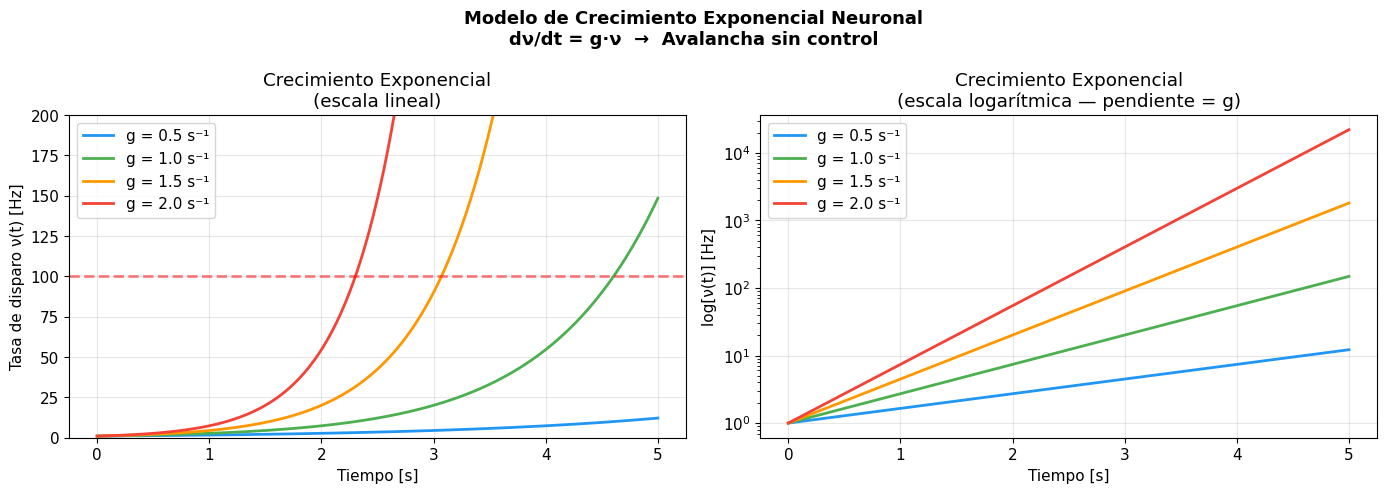

Figura 1 guardada.


In [3]:
# ============================================================
# SECCIÓN 1.1: CRECIMIENTO EXPONENCIAL (AVALANCHA NEURONAL)
# ============================================================

# --- Definición de la EDO de crecimiento exponencial ---
def crecimiento_exponencial(nu, t, g):
    """
    EDO: dnu/dt = g * nu
    nu: tasa de disparo actual [Hz]
    t:  tiempo [s] (requerido por odeint aunque no aparezca explícitamente)
    g:  ganancia sináptica [1/s]
    """
    return g * nu  # La derivada es proporcional al estado actual: retroalimentación positiva pura

# --- Parámetros físicos del sistema ---
nu0 = 1.0       # Condición inicial: 1 Hz (actividad de reposo mínima)
t = np.linspace(0, 5, 500)  # Vector de tiempo: 0 a 5 segundos, 500 puntos

# --- Simulación para distintas ganancias sinápticas ---
# Variamos g para mostrar cómo la tasa de amplificación cambia el comportamiento
ganancias = [0.5, 1.0, 1.5, 2.0]   # Distintos valores de ganancia sináptica [1/s]
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']  # Colores para cada curva

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica en escala lineal ---
for g, color in zip(ganancias, colores):
    # odeint resuelve la EDO numéricamente usando el método LSODA (adaptativo)
    nu_sol = odeint(crecimiento_exponencial, nu0, t, args=(g,))
    axes[0].plot(t, nu_sol, color=color, label=f'g = {g} s⁻¹')

axes[0].set_xlabel('Tiempo [s]')
axes[0].set_ylabel('Tasa de disparo ν(t) [Hz]')
axes[0].set_title('Crecimiento Exponencial\n(escala lineal)')
axes[0].legend()
axes[0].set_ylim(0, 200)  # Limitamos el eje y para visualizar el inicio de la explosión
axes[0].axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Límite fisiológico típico')

# --- Gráfica en escala logarítmica (muestra la linealidad del exponencial en log) ---
for g, color in zip(ganancias, colores):
    nu_sol = odeint(crecimiento_exponencial, nu0, t, args=(g,))
    # En escala log, exp(gt) aparece como línea recta con pendiente g
    axes[1].semilogy(t, nu_sol, color=color, label=f'g = {g} s⁻¹')

axes[1].set_xlabel('Tiempo [s]')
axes[1].set_ylabel('log[ν(t)] [Hz]')
axes[1].set_title('Crecimiento Exponencial\n(escala logarítmica — pendiente = g)')
axes[1].legend()

plt.suptitle('Modelo de Crecimiento Exponencial Neuronal\ndν/dt = g·ν  →  Avalancha sin control', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_exponencial.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 1 guardada.")


## 1.2 Modelo Logístico: Saturación y Capacidad de Carga

Para hacer el modelo físicamente realista, introducimos la **refractariedad neuronal**: cuando la tasa de disparo $\nu$ se acerca al máximo fisiológico $\nu_{max}$, la tasa de crecimiento efectiva decae a cero.

### Ecuación logística

$$\frac{d\nu}{dt} = g \cdot \nu(t) \left(1 - \frac{\nu(t)}{\nu_{max}}\right)$$

**Significado físico del término de saturación:**
- El factor $\left(1 - \frac{\nu}{\nu_{max}}\right)$ actúa como un **freno dependiente del estado**: a baja actividad ($\nu \ll \nu_{max}$), el crecimiento es casi exponencial; a alta actividad ($\nu \to \nu_{max}$), el freno domina y la derivada tiende a cero.
- $\nu_{max}$ [Hz]: **Capacidad de carga** de la red. Físicamente, es el límite impuesto por el **período refractario absoluto** de las neuronas: si el período refractario es $\tau_r = 2$ ms, la frecuencia máxima es $\nu_{max} = 1/\tau_r = 500$ Hz (en la práctica, valores típicos de corteza son 20–80 Hz).
- Este modelo pertenece a la familia de **ecuaciones de Van der Pol / Bernoulli** con equilibrios analíticamente calculables.

### Interpretación termodinámica
El modelo logístico es análogo al **llenado de un capacitor** con resistencia no lineal: la corriente (análoga a $d\nu/dt$) cae a cero cuando la carga alcanza el valor máximo que el sistema puede sostener.


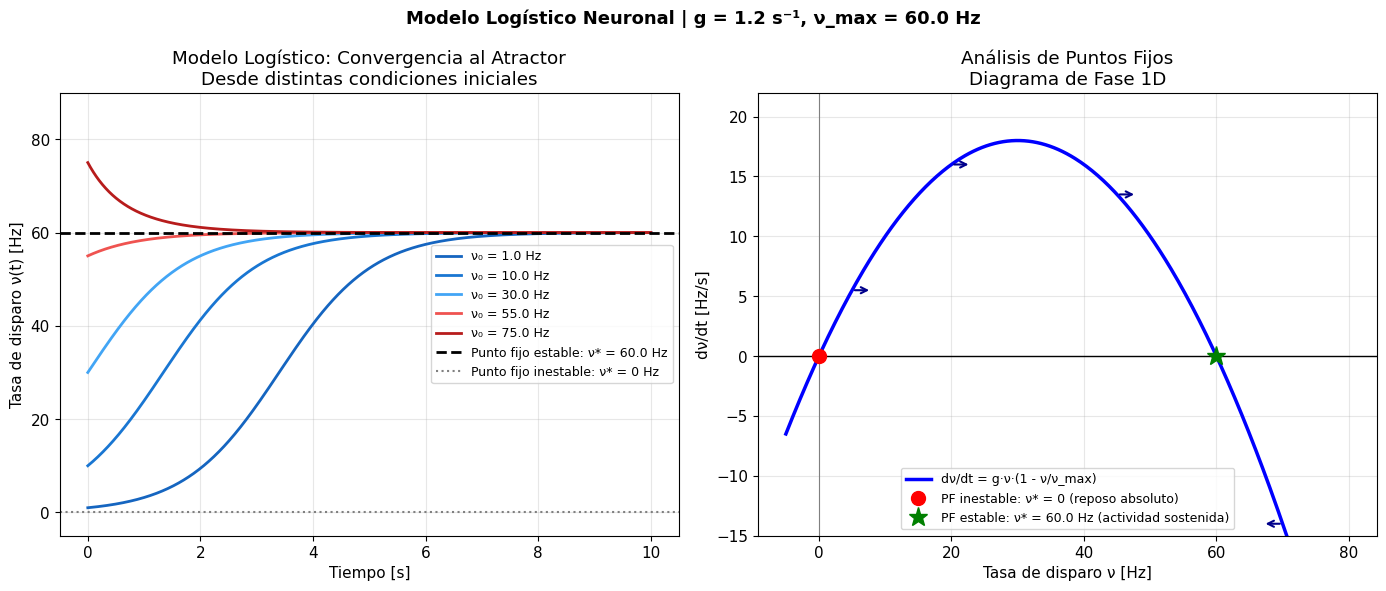

ANÁLISIS DE PUNTOS FIJOS — dν/dt = 0
Ecuación: g·ν·(1 - ν/ν_max) = 0

Punto Fijo 1 (TRIVIAL):    ν* = 0 Hz
  → Significado físico: Red completamente silente (estado de reposo absoluto)
  → Estabilidad: INESTABLE (cualquier perturbación lleva al sistema a ν_max)

Punto Fijo 2 (NO TRIVIAL): ν* = ν_max = 60.0 Hz
  → Significado físico: Red en actividad sostenida máxima (estado UP)
  → Estabilidad: ESTABLE (atractor global para toda condición inicial ν₀ > 0)

Tiempo característico de relajación: τ = 1/g = 0.83 s


In [4]:
# ============================================================
# SECCIÓN 1.2: MODELO LOGÍSTICO Y ANÁLISIS DE PUNTOS FIJOS
# ============================================================

# --- Definición de la EDO logística ---
def logistico(nu, t, g, nu_max):
    """
    EDO logística: dnu/dt = g * nu * (1 - nu/nu_max)
    nu:     tasa de disparo actual [Hz]
    t:      tiempo [s]
    g:      ganancia sináptica [1/s]
    nu_max: tasa de disparo máxima fisiológica [Hz]
    """
    return g * nu * (1.0 - nu / nu_max)

# --- Parámetros físicos ---
g = 1.2          # Ganancia sináptica [1/s]: amplificación de la red
nu_max = 60.0    # Tasa máxima [Hz]: límite por refractariedad (típico de corteza cerebral)
t = np.linspace(0, 10, 1000)  # Simulación de 10 segundos

# --- Condiciones iniciales variadas ---
# Mostramos que el sistema converge a nu_max independientemente de la condición inicial
condiciones_iniciales = [1.0, 10.0, 30.0, 55.0, 75.0]  # [Hz]: desde reposo hasta sobreactividad
colores_ci = ['#1565C0', '#1976D2', '#42A5F5', '#EF5350', '#B71C1C']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel izquierdo: evolución temporal ---
for nu0_val, color in zip(condiciones_iniciales, colores_ci):
    # Integración numérica de la EDO logística
    nu_sol = odeint(logistico, nu0_val, t, args=(g, nu_max))
    axes[0].plot(t, nu_sol, color=color, label=f'ν₀ = {nu0_val} Hz')

# Línea de puntos fijos para referencia visual
axes[0].axhline(y=nu_max, color='black', linestyle='--', linewidth=2, 
                label=f'Punto fijo estable: ν* = {nu_max} Hz')
axes[0].axhline(y=0, color='gray', linestyle=':', linewidth=1.5,
                label='Punto fijo inestable: ν* = 0 Hz')
axes[0].set_xlabel('Tiempo [s]')
axes[0].set_ylabel('Tasa de disparo ν(t) [Hz]')
axes[0].set_title('Modelo Logístico: Convergencia al Atractor\nDesde distintas condiciones iniciales')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-5, 90)

# --- Panel derecho: diagrama de fase (campo vectorial dν/dt vs ν) ---
# Este diagrama muestra la "velocidad" del sistema en cada estado
nu_vals = np.linspace(-5, 80, 400)  # Barrido de posibles tasas de disparo

# Calculamos dν/dt para cada valor de ν: es el "campo de velocidades" del sistema
dnu_dt = g * nu_vals * (1.0 - nu_vals / nu_max)

axes[1].plot(nu_vals, dnu_dt, 'b-', linewidth=2.5, label='dν/dt = g·ν·(1 - ν/ν_max)')
axes[1].axhline(0, color='black', linewidth=1)   # Eje horizontal: dν/dt = 0
axes[1].axvline(0, color='gray', linewidth=0.8)  # Eje vertical: ν = 0

# Marcar puntos fijos: donde dν/dt = 0
# Punto fijo 1: ν* = 0 (INESTABLE: cualquier perturbación aleja el sistema)
axes[1].plot(0, 0, 'ro', markersize=10, zorder=5, label='PF inestable: ν* = 0 (reposo absoluto)')
# Punto fijo 2: ν* = nu_max (ESTABLE: el sistema regresa si lo perturbamos)
axes[1].plot(nu_max, 0, 'g*', markersize=14, zorder=5, label=f'PF estable: ν* = {nu_max} Hz (actividad sostenida)')

# Flechas de flujo: indican hacia dónde se mueve el sistema
for nu_arrow in [5, 20, 45, 70]:
    dnu = g * nu_arrow * (1 - nu_arrow/nu_max)
    axes[1].annotate('', xy=(nu_arrow + 3*np.sign(dnu), dnu), 
                     xytext=(nu_arrow, dnu),
                     arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5))

axes[1].set_xlabel('Tasa de disparo ν [Hz]')
axes[1].set_ylabel('dν/dt [Hz/s]')
axes[1].set_title('Análisis de Puntos Fijos\nDiagrama de Fase 1D')
axes[1].legend(fontsize=9)
axes[1].set_ylim(-15, 22)

plt.suptitle(f'Modelo Logístico Neuronal | g = {g} s⁻¹, ν_max = {nu_max} Hz', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_logistico.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Cálculo analítico de los puntos fijos ---
print("=" * 55)
print("ANÁLISIS DE PUNTOS FIJOS — dν/dt = 0")
print("=" * 55)
print(f"Ecuación: g·ν·(1 - ν/ν_max) = 0")
print(f"")
print(f"Punto Fijo 1 (TRIVIAL):    ν* = 0 Hz")
print(f"  → Significado físico: Red completamente silente (estado de reposo absoluto)")
print(f"  → Estabilidad: INESTABLE (cualquier perturbación lleva al sistema a ν_max)")
print(f"")
print(f"Punto Fijo 2 (NO TRIVIAL): ν* = ν_max = {nu_max} Hz")
print(f"  → Significado físico: Red en actividad sostenida máxima (estado UP)")
print(f"  → Estabilidad: ESTABLE (atractor global para toda condición inicial ν₀ > 0)")
print(f"")
print(f"Tiempo característico de relajación: τ = 1/g = {1/g:.2f} s")


## 1.3 Interpretación Física de los Resultados

### Sobre el diagrama de fase 1D

El diagrama de fase (campo vectorial $d\nu/dt$ vs $\nu$) es una herramienta fundamental de la teoría de sistemas dinámicos. Cada punto en el eje horizontal representa un posible estado del sistema. La función $d\nu/dt$ nos dice:

- Si $d\nu/dt > 0$: la actividad **aumenta** (las flechas apuntan a la derecha)
- Si $d\nu/dt < 0$: la actividad **disminuye** (las flechas apuntan a la izquierda)
- Si $d\nu/dt = 0$: el sistema está en **equilibrio** (punto fijo)

### Significado neuronal de los puntos fijos

| Punto Fijo | Valor | Tipo | Interpretación neuronal |
|---|---|---|---|
| Trivial | $\nu^* = 0$ Hz | **Inestable** | Red completamente silente; cualquier perturbación (ruido sináptico) desencadena actividad |
| No trivial | $\nu^* = \nu_{max}$ | **Estable (atractor)** | Estado UP: actividad sostenida en el límite fisiológico |

Este resultado es físicamente análogo a un **potencial de doble pozo**: el sistema tiene un mínimo de energía (atractor) en $\nu_{max}$ y una barrera inestable en $\nu = 0$. En el cerebro, estados Up/Down corresponden a alternancia entre períodos de alta y baja actividad cortical observados durante el sueño.

### Limitación del modelo continuo

El modelo logístico predice convergencia **monotónica** a $\nu_{max}$, sin oscilaciones. En la realidad, las redes neuronales corticales exhiben oscilaciones (gamma, beta, alpha) que requieren al menos dos poblaciones acopladas (ver Sección 3).


---
# SECCIÓN 2: Dinámica Discreta y Caos Neuronal

## Motivación física: ¿Por qué un modelo discreto?

El cerebro procesa información en **épocas temporales discretas**: los ciclos de oscilaciones gamma (~40 Hz, período ~25 ms) sincronizan la actividad cortical en ventanas temporales. En este contexto, tiene sentido modelar la actividad como una secuencia discreta $\nu_n$ (actividad en el ciclo $n$), en lugar de una función continua $\nu(t)$.

## 2.1 Mapa Logístico Discreto

$$\nu_{n+1} = r \cdot \nu_n \cdot (1 - \nu_n)$$

Normalizando $x_n = \nu_n/\nu_{max} \in [0,1]$:

$$x_{n+1} = r \cdot x_n \cdot (1 - x_n)$$

**Parámetros:**
- $x_n \in [0,1]$: Actividad normalizada en el ciclo $n$ (0 = silencio, 1 = actividad máxima)
- $r \in [0, 4]$: **Parámetro de control** (análogo a la ganancia sináptica neta, adimensional)
- El rango $r \in [0,4]$ garantiza que $x_n \in [0,1]$ se mantenga acotado

**¿Por qué aparece el caos?** La discretización introduce un **retraso temporal**: la inhibición del ciclo $n$ no actúa en el mismo ciclo, sino en el siguiente. Este retraso puede hacer que el sistema "sobre-corrija" y genere oscilaciones que se amplifican, conduciendo al caos determinista.


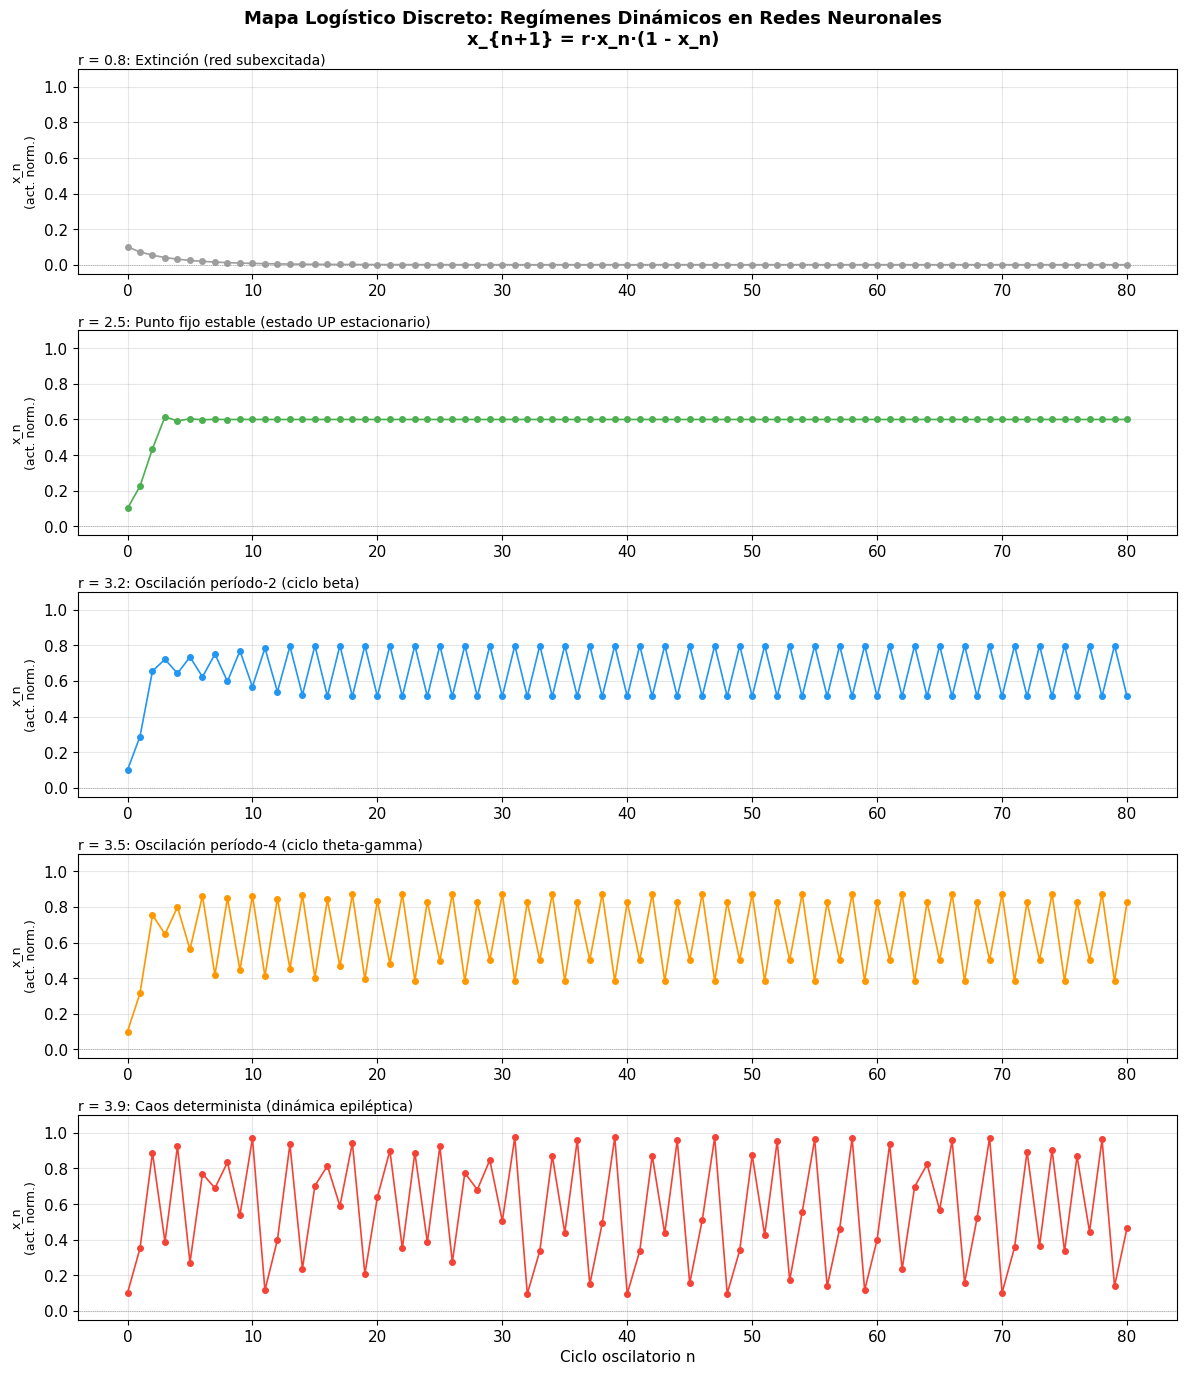

In [5]:
# ============================================================
# SECCIÓN 2: MAPA LOGÍSTICO DISCRETO Y TRANSICIÓN AL CAOS
# ============================================================

def mapa_logistico(x0, r, n_iter):
    """
    Itera el mapa logístico: x_{n+1} = r * x_n * (1 - x_n)
    x0:     condición inicial en [0,1]
    r:      parámetro de control (ganancia sináptica efectiva)
    n_iter: número de iteraciones (ciclos temporales)
    Retorna: array de longitud n_iter+1 con la trayectoria
    """
    x = np.zeros(n_iter + 1)  # Pre-alocamos el array para eficiencia
    x[0] = x0                 # Condición inicial
    for n in range(n_iter):   # Iteración del mapa
        x[n+1] = r * x[n] * (1.0 - x[n])  # La ecuación en diferencia discreta
    return x

# ============================================================
# PANEL A: Series temporales para distintos valores de r
# ============================================================
n_iter = 80   # 80 ciclos oscilatorios (equivalente a ~2 segundos en oscilaciones gamma)
x0 = 0.1     # Actividad inicial: 10% de la actividad máxima

# Valores de r que muestran los distintos regímenes dinámicos:
r_valores = [
    (0.8, 'r = 0.8: Extinción (red subexcitada)'),
    (2.5, 'r = 2.5: Punto fijo estable (estado UP estacionario)'),
    (3.2, 'r = 3.2: Oscilación período-2 (ciclo beta)'),
    (3.5, 'r = 3.5: Oscilación período-4 (ciclo theta-gamma)'),
    (3.9, 'r = 3.9: Caos determinista (dinámica epiléptica)'),
]
colores_r = ['#9E9E9E', '#4CAF50', '#2196F3', '#FF9800', '#F44336']

fig, axes = plt.subplots(len(r_valores), 1, figsize=(12, 14))

for ax, (r_val, etiqueta), color in zip(axes, r_valores, colores_r):
    # Iterar el mapa logístico con el valor de r dado
    x_traj = mapa_logistico(x0, r_val, n_iter)
    
    # Graficar la serie temporal como escalones (stem plot) para enfatizar la naturaleza discreta
    n_ciclos = np.arange(n_iter + 1)
    ax.plot(n_ciclos, x_traj, 'o-', color=color, markersize=4, linewidth=1.2)
    ax.set_ylabel('x_n\n(act. norm.)', fontsize=9)
    ax.set_title(etiqueta, fontsize=10, loc='left', pad=3)
    ax.set_ylim(-0.05, 1.1)
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle=':')

axes[-1].set_xlabel('Ciclo oscilatorio n')
plt.suptitle('Mapa Logístico Discreto: Regímenes Dinámicos en Redes Neuronales\n'
             'x_{n+1} = r·x_n·(1 - x_n)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_series_temporales.png', dpi=150, bbox_inches='tight')
plt.show()


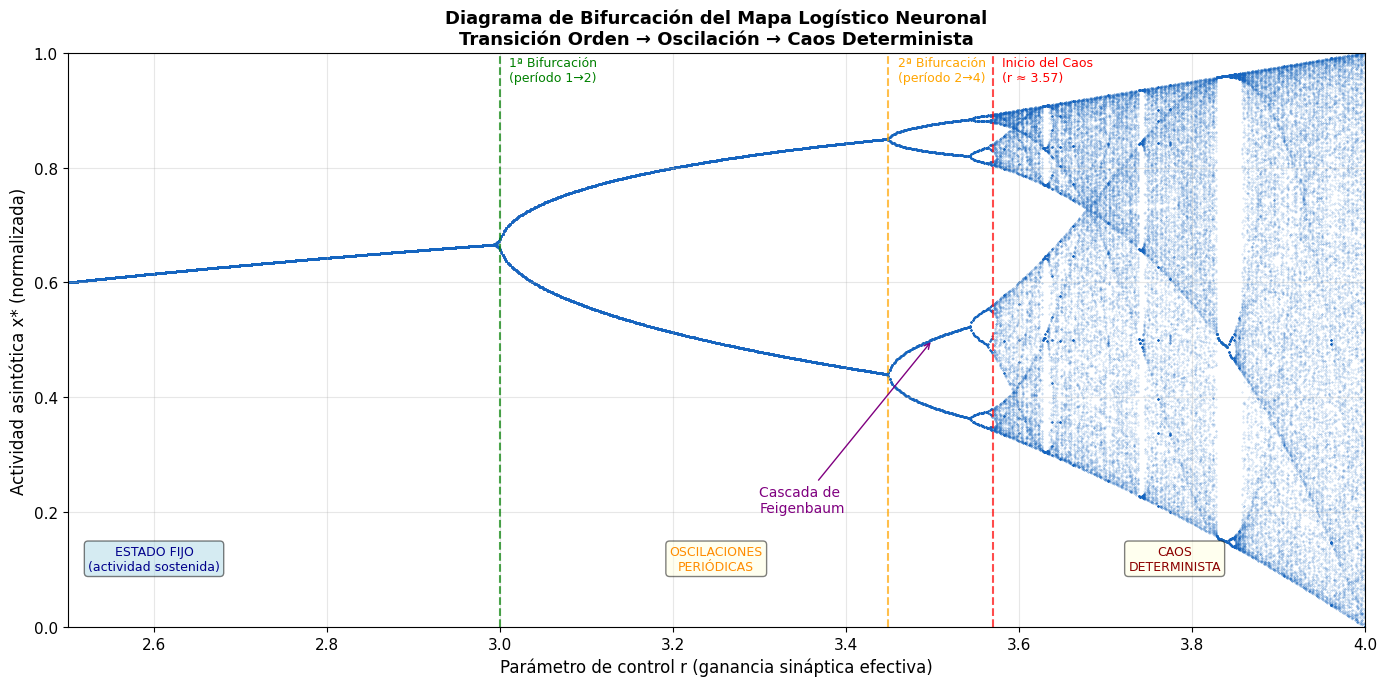

Constante de Feigenbaum (universal): δ ≈ 4.6692...
Esta constante aparece en TODOS los sistemas que muestran duplicación de período,
desde redes neuronales hasta fluidos turbulentos.


In [6]:
# ============================================================
# SECCIÓN 2.3: DIAGRAMA DE BIFURCACIÓN
# ============================================================
# El diagrama de bifurcación es la "huella digital" del sistema dinámico:
# muestra, para cada valor de r, cuáles son los estados asintóticos
# (atractores) a los que converge el sistema

# --- Parámetros del cálculo ---
r_min, r_max = 2.5, 4.0   # Rango de r donde ocurren bifurcaciones (r < 2.5 es trivial)
n_r = 1000                 # Número de valores de r a explorar
n_transiente = 500         # Iteraciones descartadas para eliminar el transitorio inicial
n_registro = 200           # Iteraciones registradas (el atractor)

r_array = np.linspace(r_min, r_max, n_r)  # Array de valores de r a explorar

# Pre-alocamos arrays para almacenar los resultados del diagrama de bifurcación
r_bifurc = []   # Valores de r (se repiten para cada punto del atractor)
x_bifurc = []   # Valores de x del atractor para cada r

# --- Cálculo del diagrama de bifurcación ---
for r in r_array:
    x = 0.5   # Condición inicial fija para todos los r (la elección no importa para el atractor)
    
    # Descartamos el transitorio: el sistema se "olvida" de la condición inicial
    for _ in range(n_transiente):
        x = r * x * (1.0 - x)
    
    # Registramos el atractor: los estados que el sistema visita indefinidamente
    for _ in range(n_registro):
        x = r * x * (1.0 - x)
        r_bifurc.append(r)  # Guardamos el r correspondiente
        x_bifurc.append(x)  # Guardamos el estado del atractor

# --- Visualización ---
fig, ax = plt.subplots(figsize=(14, 7))

# Graficamos como scatter con puntos muy pequeños y semitransparentes
# para que las regiones densas (atractores) sean visibles
ax.scatter(r_bifurc, x_bifurc, s=0.1, c='#1565C0', alpha=0.3, rasterized=True)

# Anotamos las regiones de interés neurológico
ax.axvline(x=3.0, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(3.01, 0.95, '1ª Bifurcación\n(período 1→2)', fontsize=9, color='green')

ax.axvline(x=3.449, color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(3.46, 0.95, '2ª Bifurcación\n(período 2→4)', fontsize=9, color='orange')

ax.axvline(x=3.57, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(3.58, 0.95, 'Inicio del Caos\n(r ≈ 3.57)', fontsize=9, color='red')

# Añadimos una flecha indicando la cascada de duplicación de período
ax.annotate('Cascada de\nFeigenbaum', xy=(3.5, 0.5), xytext=(3.3, 0.2),
            arrowprops=dict(arrowstyle='->', color='purple'),
            fontsize=10, color='purple')

ax.set_xlabel('Parámetro de control r (ganancia sináptica efectiva)', fontsize=12)
ax.set_ylabel('Actividad asintótica x* (normalizada)', fontsize=12)
ax.set_title('Diagrama de Bifurcación del Mapa Logístico Neuronal\n'
             'Transición Orden → Oscilación → Caos Determinista', fontsize=13, fontweight='bold')
ax.set_xlim(r_min, r_max)
ax.set_ylim(0, 1)

# Texto explicativo de las regiones
ax.text(2.6, 0.1, 'ESTADO FIJO\n(actividad sostenida)', fontsize=9, 
        ha='center', color='darkblue',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))
ax.text(3.25, 0.1, 'OSCILACIONES\nPERIÓDICAS', fontsize=9, 
        ha='center', color='darkorange',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.5))
ax.text(3.78, 0.1, 'CAOS\nDETERMINISTA', fontsize=9, 
        ha='center', color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('fig4_bifurcacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Constante de Feigenbaum (universal): δ ≈ 4.6692...")
print("Esta constante aparece en TODOS los sistemas que muestran duplicación de período,")
print("desde redes neuronales hasta fluidos turbulentos.")


## 2.4 Interpretación Física del Diagrama de Bifurcación

El diagrama de bifurcación revela la **estructura del espacio de parámetros**: cómo cambia cualitativamente el comportamiento del sistema al variar la ganancia sináptica $r$.

| Régimen | Rango de r | Comportamiento | Correlato neurológico |
|---|---|---|---|
| Punto fijo | $r < 3.0$ | Actividad estacionaria | Estado UP normal, actividad cortical basal |
| Período 2 | $3.0 < r < 3.449$ | Oscilación entre dos estados | Ritmo alfa (8–12 Hz) o ciclos Up-Down del sueño |
| Período 4, 8, ... | $3.449 < r < 3.57$ | Cascada de Feigenbaum | Ritmos anidados (cross-frequency coupling) |
| **Caos** | $r > 3.57$ | Aperiódico, sensible a CI | **Dinámica epiléptica** o procesamiento de información complejo |

**Importancia de la Constante de Feigenbaum ($\delta \approx 4.6692$):** La razón entre intervalos sucesivos de bifurcación es universal. Esto significa que la **ruta al caos por duplicación de período** es la misma en redes neuronales, fluidos de Rayleigh-Bénard y osciladores electrónicos. Es una propiedad topológica del espacio de fases, no del sistema específico.

**Sensibilidad a condiciones iniciales:** En el régimen caótico ($r > 3.57$), dos redes con actividades iniciales que difieren en $10^{-10}$ evolucionan de forma completamente diferente tras ~50 ciclos. El exponente de Lyapunov positivo cuantifica esta divergencia: $\lambda > 0$ indica caos.


---
# SECCIÓN 3: Interacciones en Redes — Modelo Excitatorio-Inhibitorio (E-I)

## Motivación: El balance E-I en el cerebro

Las redes neuronales corticales no están formadas por una sola población homogénea. Existe un balance fundamental entre:
- **Neuronas Excitatorias (E)**: ~80% del total, liberan glutamato, amplifican la señal
- **Neuronas Inhibitorias (I)**: ~20% del total, liberan GABA, frenan la actividad

Este balance E-I es esencial para la función cognitiva normal. Su ruptura está asociada a esquizofrenia, autismo y epilepsia.

## 3.1 Ecuaciones Diferenciales Acopladas (Lotka-Volterra Neuronal)

$$\frac{dE}{dt} = g_E \cdot E \left(1 - \frac{E}{K_E}\right) - \alpha \cdot E \cdot I$$

$$\frac{dI}{dt} = -g_I \cdot I + \beta \cdot E \cdot I$$

**Significado físico de cada término:**

| Término | Ecuación | Significado neuronal |
|---|---|---|
| $g_E \cdot E(1 - E/K_E)$ | $dE/dt$ | Crecimiento logístico autónomo de la población E (reclutamiento) |
| $-\alpha \cdot E \cdot I$ | $dE/dt$ | Inhibición de E por I (sinapsis GABA sobre células piramidales) |
| $-g_I \cdot I$ | $dI/dt$ | Decaimiento natural de la actividad inhibitoria (sin excitación se silencia) |
| $+\beta \cdot E \cdot I$ | $dI/dt$ | Reclutamiento de I por E (sinapsis glutamatérgicas sobre interneuronas) |

**Parámetros:**
- $E(t)$, $I(t)$ [Hz]: Tasas de disparo de poblaciones excitatoria e inhibitoria
- $g_E$ [s⁻¹]: Ganancia de la red excitatoria (autónoma)
- $K_E$ [Hz]: Capacidad de carga excitatoria (límite fisiológico)
- $\alpha$ [Hz⁻¹·s⁻¹]: Eficacia sináptica GABA (cuánta inhibición por disparo inhibitorio)
- $g_I$ [s⁻¹]: Tasa de decaimiento de interneuronas
- $\beta$ [Hz⁻¹·s⁻¹]: Eficacia sináptica glutamatérgica sobre interneuronas


Punto fijo del sistema E-I:
  E* = gI/β  = 26.7 Hz  (actividad excitatoria de equilibrio)
  I* = gE(1-E*/KE)/α = 9.3 Hz  (actividad inhibitoria de equilibrio)


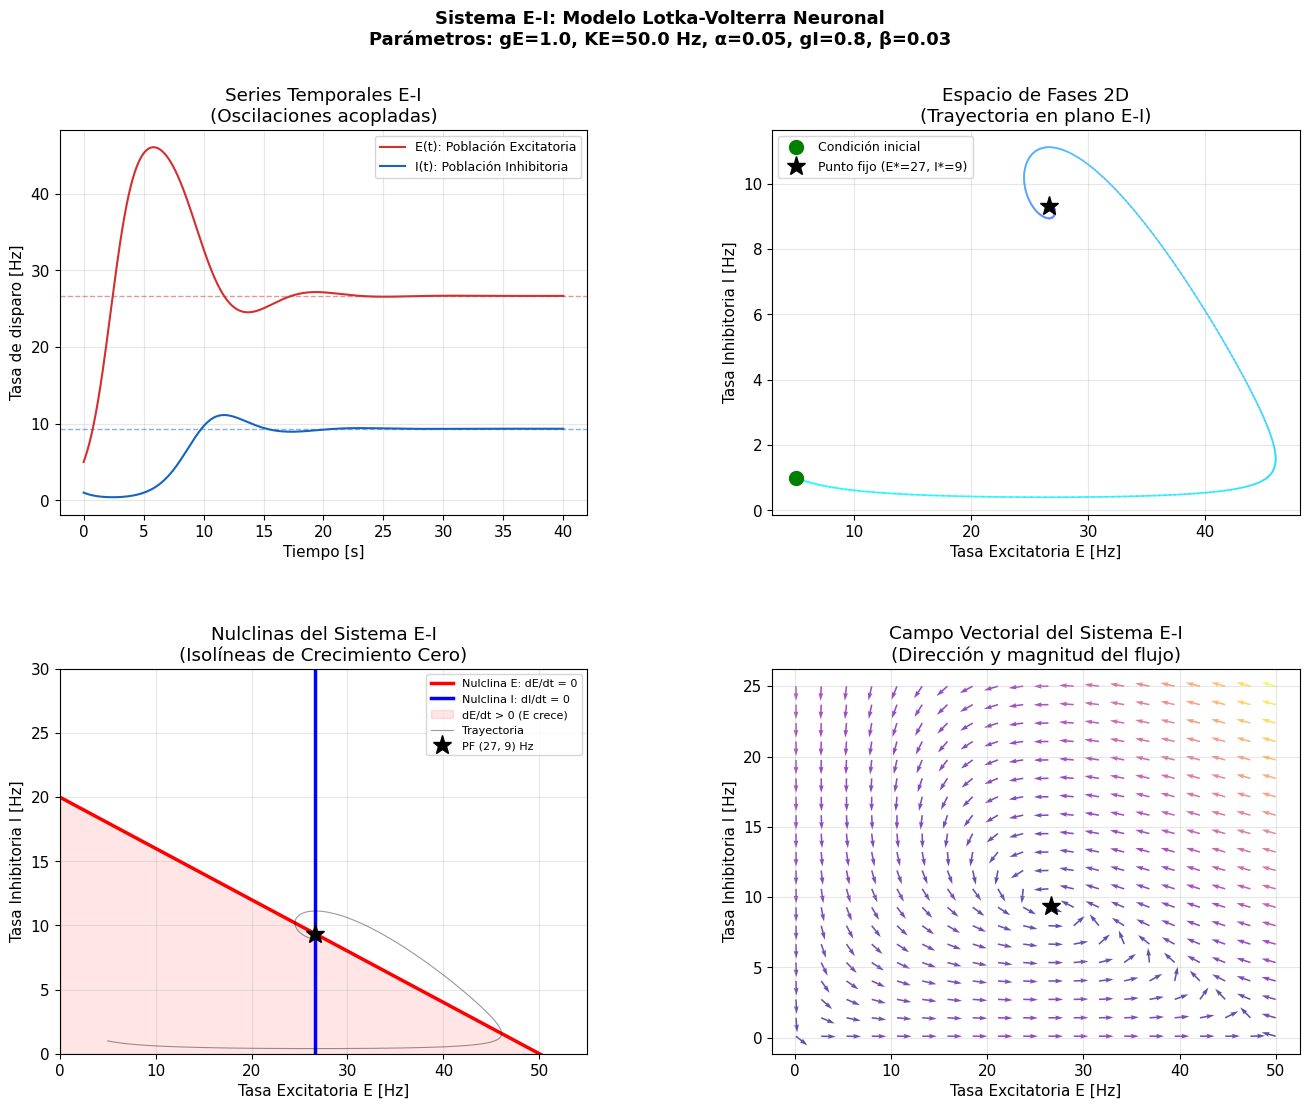

In [7]:
# ============================================================
# SECCIÓN 3: RED EXCITATORIA-INHIBITORIA (MODELO E-I)
# ============================================================

# --- Definición del sistema de EDOs acopladas ---
def sistema_EI(estado, t, gE, KE, alpha, gI, beta):
    """
    Sistema E-I tipo Lotka-Volterra neuronal:
    dE/dt = gE*E*(1 - E/KE) - alpha*E*I   (excitatorio)
    dI/dt = -gI*I + beta*E*I              (inhibitorio)
    
    estado: [E, I] — tasas de disparo actuales [Hz]
    t:      tiempo [s]
    gE:     ganancia excitatoria autónoma [1/s]
    KE:     capacidad de carga excitatoria [Hz]
    alpha:  eficacia sináptica GABA [1/(Hz·s)]
    gI:     tasa de decaimiento inhibitorio [1/s]
    beta:   eficacia sináptica glutamatérgica sobre I [1/(Hz·s)]
    """
    E, I = estado  # Desempaquetamos el vector de estado
    
    # Ecuación para la población excitatoria:
    # Crecimiento logístico propio MENOS inhibición recibida de I
    dE_dt = gE * E * (1.0 - E/KE) - alpha * E * I
    
    # Ecuación para la población inhibitoria:
    # Decaimiento propio (sin sustento se silencia) MÁS reclutamiento por E
    dI_dt = -gI * I + beta * E * I
    
    return [dE_dt, dI_dt]

# --- Parámetros físicos del sistema E-I ---
gE    = 1.0    # Ganancia excitatoria [1/s]
KE    = 50.0   # Capacidad máxima de E [Hz]: límite fisiológico excitatorio
alpha = 0.05   # Eficacia GABA: cada Hz inhibitorio suprime 0.05 Hz excitatorio
gI    = 0.8    # Decaimiento inhibitorio [1/s]: más rápido que la excitación
beta  = 0.03   # Eficacia glutamatérgica sobre I: reclutamiento de interneuronas

# --- Cálculo del punto fijo del sistema ---
# Igualando dI/dt = 0: E* = gI/beta
E_star = gI / beta
# Igualando dE/dt = 0 (con E ≠ 0): I* = gE*(1 - E*/KE)/alpha
I_star = gE * (1.0 - E_star/KE) / alpha
print(f"Punto fijo del sistema E-I:")
print(f"  E* = gI/β  = {E_star:.1f} Hz  (actividad excitatoria de equilibrio)")
print(f"  I* = gE(1-E*/KE)/α = {I_star:.1f} Hz  (actividad inhibitoria de equilibrio)")

# --- Simulación dinámica ---
t = np.linspace(0, 40, 4000)     # 40 segundos de evolución temporal
estado0 = [5.0, 1.0]             # Condición inicial: E=5 Hz, I=1 Hz (red poco activa)

# Integramos el sistema de EDOs con odeint
sol = odeint(sistema_EI, estado0, t, 
             args=(gE, KE, alpha, gI, beta),
             rtol=1e-8, atol=1e-10)  # Tolerancias altas para precisión en ciclos límite

E_t = sol[:, 0]   # Extraemos la solución para E(t)
I_t = sol[:, 1]   # Extraemos la solución para I(t)

# ============================================================
# FIGURA: 4 paneles — series temporales, espacio de fases, nulclinas
# ============================================================
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# --- Panel 1: Series temporales E(t) e I(t) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t, E_t, color='#D32F2F', linewidth=1.5, label='E(t): Población Excitatoria')
ax1.plot(t, I_t, color='#1565C0', linewidth=1.5, label='I(t): Población Inhibitoria')
ax1.axhline(E_star, color='#D32F2F', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(I_star, color='#1565C0', linestyle='--', alpha=0.5, linewidth=1)
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Tasa de disparo [Hz]')
ax1.set_title('Series Temporales E-I\n(Oscilaciones acopladas)')
ax1.legend(fontsize=9)

# --- Panel 2: Espacio de fases (E vs I) con trayectoria ---
ax2 = fig.add_subplot(gs[0, 1])
# Coloreamos la trayectoria por tiempo (de azul a rojo) para mostrar la evolución
n_pts = len(t)
for k in range(0, n_pts-1, 5):
    frac = k / n_pts  # Fracción del tiempo transcurrido
    color_traj = plt.cm.cool(frac)
    ax2.plot(E_t[k:k+6], I_t[k:k+6], color=color_traj, linewidth=1.2, alpha=0.8)

# Marcamos el punto de partida y el punto fijo
ax2.plot(estado0[0], estado0[1], 'go', markersize=10, zorder=5, label='Condición inicial')
ax2.plot(E_star, I_star, 'k*', markersize=14, zorder=5, label=f'Punto fijo (E*={E_star:.0f}, I*={I_star:.0f})')
ax2.set_xlabel('Tasa Excitatoria E [Hz]')
ax2.set_ylabel('Tasa Inhibitoria I [Hz]')
ax2.set_title('Espacio de Fases 2D\n(Trayectoria en plano E-I)')
ax2.legend(fontsize=9)

# --- Panel 3: Nulclinas (isolíneas de crecimiento cero) ---
ax3 = fig.add_subplot(gs[1, 0])

E_range = np.linspace(0.1, KE*1.1, 300)  # Barrido de valores de E para nulclinas

# NULCLINA DE E: dE/dt = 0 → gE*(1-E/KE) = alpha*I → I = gE*(1-E/KE)/alpha
# Representa los estados donde la actividad E no cambia
I_nullcline_E = gE * (1.0 - E_range/KE) / alpha  # Solo válida donde I > 0

# NULCLINA DE I: dI/dt = 0 → E = gI/beta (línea vertical)
# La población inhibitoria no cambia cuando E es exactamente E*
E_nullcline_I = np.full_like(E_range, E_star)  # Línea vertical en E = E*
I_range = np.linspace(0, 30, 300)

ax3.plot(E_range, I_nullcline_E, 'r-', linewidth=2.5, label='Nulclina E: dE/dt = 0')
ax3.axvline(x=E_star, color='blue', linewidth=2.5, label='Nulclina I: dI/dt = 0')

# Sombreado de regiones donde dE/dt > 0 y dI/dt > 0
ax3.fill_between(E_range, 0, I_nullcline_E, where=(I_nullcline_E > 0),
                  alpha=0.1, color='red', label='dE/dt > 0 (E crece)')

# Graficamos la trayectoria sobre las nulclinas
ax3.plot(E_t[::3], I_t[::3], 'k-', linewidth=0.8, alpha=0.4, label='Trayectoria')

# Punto fijo en la intersección de las nulclinas
ax3.plot(E_star, I_star, 'k*', markersize=14, zorder=5, label=f'PF ({E_star:.0f}, {I_star:.0f}) Hz')

ax3.set_xlabel('Tasa Excitatoria E [Hz]')
ax3.set_ylabel('Tasa Inhibitoria I [Hz]')
ax3.set_title('Nulclinas del Sistema E-I\n(Isolíneas de Crecimiento Cero)')
ax3.legend(fontsize=8)
ax3.set_xlim(0, KE * 1.1)
ax3.set_ylim(0, 30)

# --- Panel 4: Campo vectorial del sistema ---
ax4 = fig.add_subplot(gs[1, 1])

# Creamos una malla de puntos para el campo vectorial
E_mesh = np.linspace(0.1, 50, 20)
I_mesh = np.linspace(0.1, 25, 20)
EE, II = np.meshgrid(E_mesh, I_mesh)  # Malla 2D del espacio de fases

# Calculamos la derivada en cada punto de la malla
dE = gE * EE * (1.0 - EE/KE) - alpha * EE * II  # dE/dt en cada punto
dI = -gI * II + beta * EE * II                    # dI/dt en cada punto

# Normalizamos las flechas para que todas tengan la misma longitud (solo dirección)
magnitud = np.sqrt(dE**2 + dI**2) + 1e-10  # Evitamos división por cero
ax4.quiver(EE, II, dE/magnitud, dI/magnitud, 
           magnitud, cmap='plasma', alpha=0.7)
ax4.plot(E_star, I_star, 'k*', markersize=14, zorder=5)
ax4.set_xlabel('Tasa Excitatoria E [Hz]')
ax4.set_ylabel('Tasa Inhibitoria I [Hz]')
ax4.set_title('Campo Vectorial del Sistema E-I\n(Dirección y magnitud del flujo)')

plt.suptitle('Sistema E-I: Modelo Lotka-Volterra Neuronal\n'
             f'Parámetros: gE={gE}, KE={KE} Hz, α={alpha}, gI={gI}, β={beta}',
             fontsize=13, fontweight='bold')
plt.savefig('fig5_red_EI.png', dpi=150, bbox_inches='tight')
plt.show()


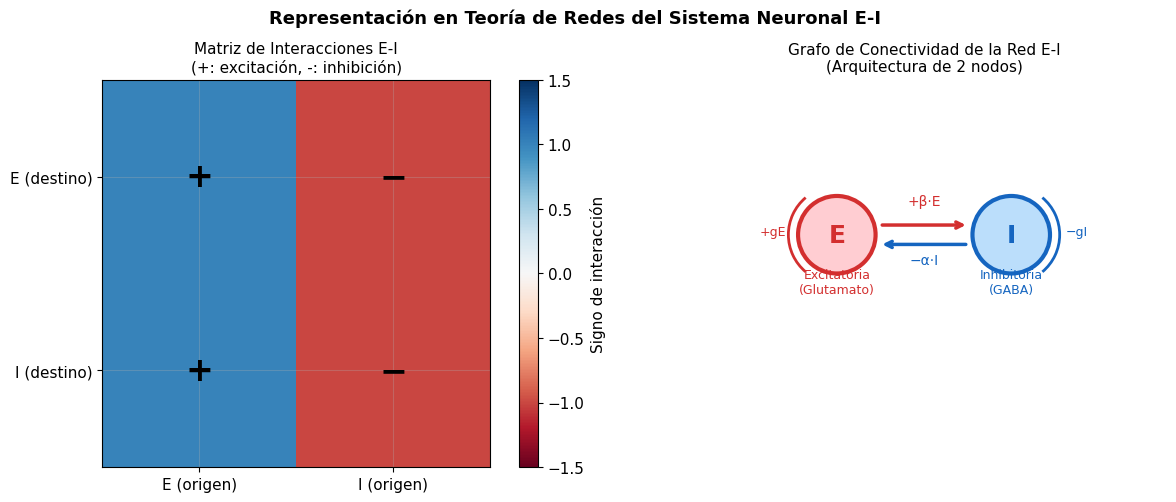

In [8]:
# ============================================================
# SECCIÓN 3.2: REPRESENTACIÓN MATRICIAL DE INTERACCIONES
# ============================================================
# En teoría de redes, las interacciones entre nodos se representan
# con matrices de conectividad (o de adyacencia ponderada).
# Para el sistema E-I, la matriz de interacciones es:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Matriz de interacciones del sistema E-I ---
# Cada elemento M[i,j] indica el efecto de j sobre i
# (+) excitación, (-) inhibición

# La matriz del Jacobiano evaluado en un punto genérico muestra los tipos de acoplamiento:
# M = [[∂(dE/dt)/∂E, ∂(dE/dt)/∂I],   [  (+/-),    (-)  ]
#      [∂(dI/dt)/∂E, ∂(dI/dt)/∂I]]     [   (+),    (+/-) ]

# Matriz simplificada de signos de interacción (en punto fijo)
# M[i,j] = efecto de j sobre i
M_signos = np.array([[1, -1],   # E se autoexcita (+) pero es inhibida por I (-)
                     [1, -1]])  # I es excitada por E (+) pero se auto-inhibe (-) 

# Visualizamos la matriz como mapa de calor
im = axes[0].imshow(M_signos, cmap='RdBu', vmin=-1.5, vmax=1.5, aspect='equal')
plt.colorbar(im, ax=axes[0], label='Signo de interacción')

# Etiquetamos filas y columnas
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['E (origen)', 'I (origen)'], fontsize=11)
axes[0].set_yticklabels(['E (destino)', 'I (destino)'], fontsize=11)
axes[0].set_title('Matriz de Interacciones E-I\n(+: excitación, -: inhibición)', fontsize=11)

# Añadimos los valores numéricos en las celdas
for i in range(2):
    for j in range(2):
        signo = '+' if M_signos[i,j] > 0 else '−'
        axes[0].text(j, i, signo, ha='center', va='center', fontsize=24, fontweight='bold',
                    color='black')

# --- Diagrama de red (grafo de conectividad) ---
# Dibujamos manualmente los nodos y aristas como un grafo dirigido
ax2 = axes[1]
ax2.set_xlim(-0.5, 2)
ax2.set_ylim(-0.5, 1.5)
ax2.set_aspect('equal')
ax2.axis('off')

# Posiciones de los nodos
pos_E = (0.3, 0.7)   # Nodo Excitatorio
pos_I = (1.2, 0.7)   # Nodo Inhibitorio

# Dibujamos los nodos como círculos
circulo_E = plt.Circle(pos_E, 0.2, color='#FFCDD2', ec='#D32F2F', linewidth=3, zorder=3)
circulo_I = plt.Circle(pos_I, 0.2, color='#BBDEFB', ec='#1565C0', linewidth=3, zorder=3)
ax2.add_patch(circulo_E)
ax2.add_patch(circulo_I)

# Etiquetas de los nodos
ax2.text(pos_E[0], pos_E[1], 'E', ha='center', va='center', fontsize=18, fontweight='bold', color='#D32F2F')
ax2.text(pos_I[0], pos_I[1], 'I', ha='center', va='center', fontsize=18, fontweight='bold', color='#1565C0')
ax2.text(pos_E[0], pos_E[1]-0.3, 'Excitatoria\n(Glutamato)', ha='center', fontsize=9, color='#D32F2F')
ax2.text(pos_I[0], pos_I[1]-0.3, 'Inhibitoria\n(GABA)', ha='center', fontsize=9, color='#1565C0')

# Arista E → I (excitación, flecha positiva)
ax2.annotate('', xy=(pos_I[0]-0.22, pos_I[1]+0.05), xytext=(pos_E[0]+0.22, pos_E[1]+0.05),
            arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=2.5))
ax2.text(0.75, 0.85, '+β·E', ha='center', fontsize=10, color='#D32F2F')

# Arista I → E (inhibición, flecha negativa)
ax2.annotate('', xy=(pos_E[0]+0.22, pos_E[1]-0.05), xytext=(pos_I[0]-0.22, pos_I[1]-0.05),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2.5))
ax2.text(0.75, 0.55, '−α·I', ha='center', fontsize=10, color='#1565C0')

# Auto-aristas (retroalimentación propia)
arco_E = plt.matplotlib.patches.Arc(pos_E, 0.5, 0.5, angle=0, theta1=130, theta2=230,
                                      color='#D32F2F', linewidth=2)
ax2.add_patch(arco_E)
ax2.text(pos_E[0]-0.4, pos_E[1], '+gE', fontsize=9, color='#D32F2F')

arco_I = plt.matplotlib.patches.Arc(pos_I, 0.5, 0.5, angle=0, theta1=-50, theta2=50,
                                      color='#1565C0', linewidth=2)
ax2.add_patch(arco_I)
ax2.text(pos_I[0]+0.28, pos_I[1], '−gI', fontsize=9, color='#1565C0')

ax2.set_title('Grafo de Conectividad de la Red E-I\n(Arquitectura de 2 nodos)', fontsize=11)

plt.suptitle('Representación en Teoría de Redes del Sistema Neuronal E-I', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_matriz_red.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.3 Análisis de Nulclinas e Interpretación del Espacio de Fases

Las nulclinas son curvas en el espacio de fases donde una de las derivadas se anula. Su intersección da los **puntos fijos** del sistema.

### Nulclina de E ($dE/dt = 0$):
$$g_E \cdot E\left(1 - \frac{E}{K_E}\right) = \alpha \cdot E \cdot I \quad \Rightarrow \quad I^* = \frac{g_E}{\alpha}\left(1 - \frac{E}{K_E}\right)$$
Es una función lineal decreciente: a mayor actividad excitatoria, se requiere más inhibición para mantener el equilibrio.

### Nulclina de I ($dI/dt = 0$):
$$-g_I \cdot I + \beta \cdot E \cdot I = 0 \quad \Rightarrow \quad E^* = \frac{g_I}{\beta}$$
Es una línea **vertical** en el espacio de fases: la actividad inhibitoria no cambia solo cuando la excitación alcanza exactamente $E^* = g_I/\beta$.

### Punto fijo del sistema
La intersección de ambas nulclinas en $(E^*, I^*)$ es el **único punto de equilibrio no trivial** del sistema. La naturaleza de este punto (estable, inestable, espiral) depende de los autovalores del Jacobiano evaluado en ese punto.

### Ciclos límite: las oscilaciones E-I
Las trayectorias en el espacio de fases forman **ciclos cerrados** alrededor del punto fijo. Esto es el correlato matemático de las **oscilaciones gamma** (30–80 Hz) observadas en corteza cerebral: la excitación recluta inhibición, que suprime la excitación, que decae la inhibición, que permite de nuevo la excitación — un ciclo perpetuo.


---
# SECCIÓN 4: Reflexión Crítica — Alcance, Limitaciones y Extensiones del Modelo

## 4.1 ¿Qué captura bien este modelo?

El enfoque de **ecuaciones diferenciales de campo medio** (mean-field) para poblaciones neuronales tiene fortalezas significativas:

1. **Captura la dinámica colectiva emergente:** Los ciclos E-I del espacio de fases reproducen cualitativamente las oscilaciones gamma observadas en EEG/LFP sin necesidad de simular millones de neuronas.
2. **Análisis de estabilidad tractable:** Los puntos fijos, nulclinas y bifurcaciones pueden calcularse analíticamente, permitiendo predicciones sobre transiciones de fase (por ejemplo, cuándo la red entra en estado epiléptico).
3. **Universalidad:** La estructura matemática (Lotka-Volterra) es la misma que aparece en reacciones químicas oscilantes (Brusselator, Belousov-Zhabotinsky) y osciladores acoplados en física de plasma.
4. **Diagrama de bifurcación:** Identifica parámetros críticos ($r$, $g$, $\alpha/\beta$) donde el sistema cambia cualitativamente de comportamiento — útil para modelar efectos de fármacos (modifican $\alpha$ o $\beta$).

## 4.2 Limitaciones físicas fundamentales

### Frente a modelos de neuronas individuales (Integrate-and-Fire, Hodgkin-Huxley)

| Aspecto | Modelo de Campo Medio (este trabajo) | Modelo de Neurona Individual |
|---|---|---|
| Resolución temporal | Variables continuas en tiempo continuo | Disparos discretos (spikes) en tiempo real |
| Correlaciones | Ignoradas (hipótesis de campo medio) | Capturadas explícitamente |
| Plasticidad sináptica | No incluida | Se puede modelar (STDP) |
| Heterogeneidad | Neuronas idénticas (promedio) | Distribución de parámetros |
| Geometría espacial | Sin estructura espacial | Redes con posición, axones, dendritas |
| Computabilidad | O(1) parámetros | O(N) neuronas, O(N²) sinapsis |

### Frente a autómatas celulares neuronales
Los autómatas (como el modelo de Hopfield o el Greenberg-Hastings) capturan la **propagación espacial** de la actividad (frentes de activación, ondas de despolarización), que el modelo de campo medio ignora completamente. Para modelar epilepsia focal o propagación de ondas corticales, los autómatas son superiores.

## 4.3 Posibles mejoras físicas

1. **Incluir retraso temporal ($\tau$):** Las sinapsis no son instantáneas. Introducir un retraso $\tau$ en la inhibición:
   $$\frac{dE}{dt} = g_E E(1-E/K_E) - \alpha E \cdot I(t-\tau)$$
   Los retrasos convierten el sistema de EDOs en una **ecuación diferencial con retraso** (DDE), que puede generar oscilaciones incluso sin ciclos límite, y enriquece enormemente el diagrama de bifurcación.

2. **Extensión a N poblaciones (red):** En lugar de solo E e I, modelar múltiples columnas corticales acopladas:
   $$\frac{d\nu_i}{dt} = \sum_j W_{ij} \cdot \sigma(\nu_j) - \nu_i/\tau$$
   donde $W_{ij}$ es la **matriz de conectividad de la red** y $\sigma$ es una función de activación sigmoide. Esto conecta directamente con las **redes neuronales artificiales** y permite analizar propiedades como conectividad, centralidad y modularidad.

3. **Ruido estocástico:** Las redes biológicas son ruidosas. Añadir un término de ruido gaussiano:
   $$\frac{dE}{dt} = f(E,I) + \sqrt{2D} \cdot \xi(t)$$
   convierte el sistema en una **ecuación diferencial estocástica (SDE)**, permitiendo estudiar transiciones inducidas por ruido (como en teoría de Kramers para barreras de potencial).

4. **Plasticidad sináptica (STDP):** Las conexiones $\alpha$ y $\beta$ no son constantes, sino que cambian según la historia de actividad (Spike-Timing Dependent Plasticity). Esto hace el sistema **no autónomo** y capaz de aprender.

## 4.4 Conclusión: El modelamiento como herramienta física

Este trabajo ilustra que los mismos formalismos matemáticos que describen **reacciones químicas oscilantes**, **fluidos turbulentos** y **sistemas de Lotka-Volterra ecológicos** son directamente aplicables a la **dinámica de redes neuronales**. La elección del modelo de campo medio continuo es adecuada cuando:
- El número de neuronas es grande ($N \gg 1$)
- Nos interesa la dinámica temporal colectiva, no los disparos individuales
- Queremos análisis analítico de estabilidad y bifurcaciones

Las ecuaciones diferenciales, los diagramas de bifurcación y el análisis de puntos fijos son **instrumentos universales** de la física matemática, cuyo poder radica precisamente en su independencia del sustrato: describen el cerebro, el clima y los ecosistemas con las mismas herramientas. Esto no es accidental — refleja la **universalidad de las leyes de los sistemas dinámicos no lineales**.


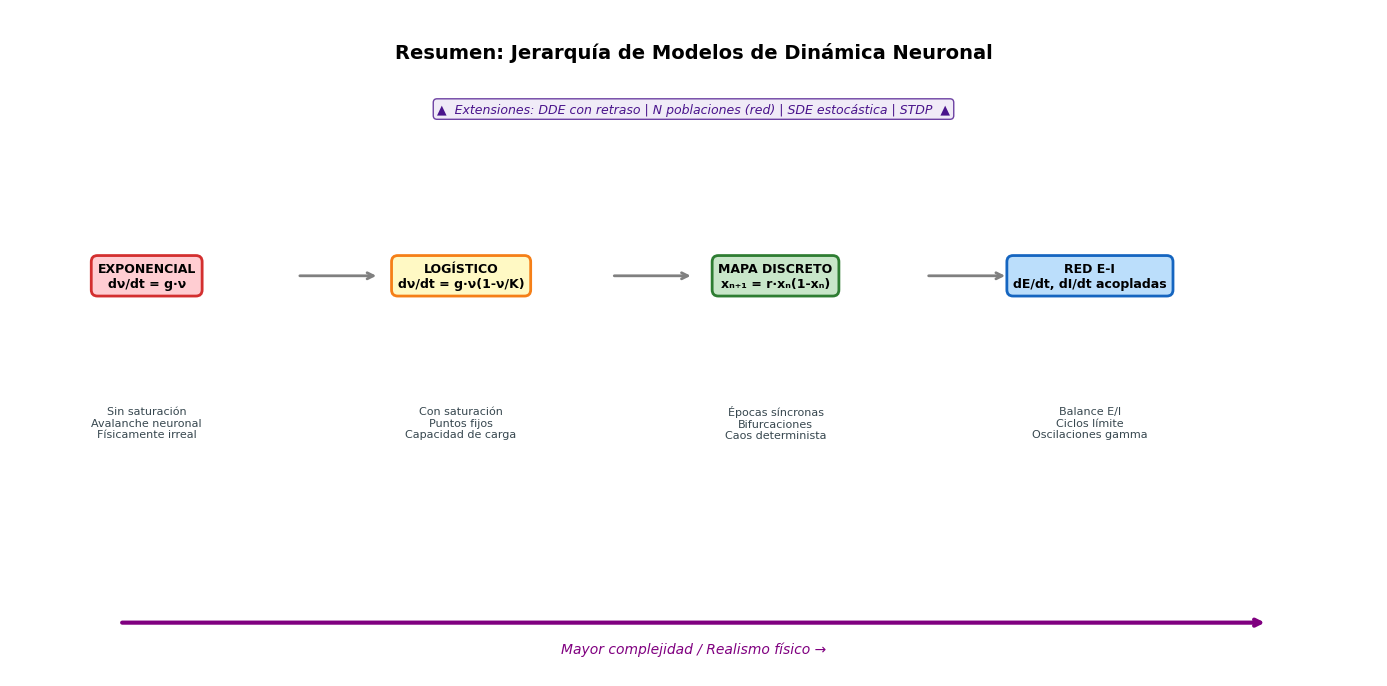


NOTEBOOK COMPLETADO
Figuras generadas:
  1. fig1_exponencial.png       → Crecimiento exponencial
  2. fig2_logistico.png         → Modelo logístico y puntos fijos
  3. fig3_series_temporales.png → Regímenes del mapa discreto
  4. fig4_bifurcacion.png       → Diagrama de bifurcación
  5. fig5_red_EI.png            → Dinámica de la red E-I
  6. fig6_matriz_red.png        → Matriz de conectividad
  7. fig7_resumen.png           → Mapa conceptual resumen


In [9]:
# ============================================================
# FIGURA RESUMEN: Mapa conceptual de los modelos estudiados
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

# Título principal
ax.text(0.5, 0.95, 'Resumen: Jerarquía de Modelos de Dinámica Neuronal',
        ha='center', va='top', fontsize=14, fontweight='bold', transform=ax.transAxes)

# Cuadros de los modelos
modelos = [
    (0.10, 0.6, 'EXPONENCIAL\ndν/dt = g·ν', '#FFCDD2', '#D32F2F',
     'Sin saturación\nAvalanche neuronal\nFísicamente irreal'),
    (0.33, 0.6, 'LOGÍSTICO\ndν/dt = g·ν(1-ν/K)', '#FFF9C4', '#F57F17',
     'Con saturación\nPuntos fijos\nCapacidad de carga'),
    (0.56, 0.6, 'MAPA DISCRETO\nxₙ₊₁ = r·xₙ(1-xₙ)', '#C8E6C9', '#2E7D32',
     'Épocas síncronas\nBifurcaciones\nCaos determinista'),
    (0.79, 0.6, 'RED E-I\ndE/dt, dI/dt acopladas', '#BBDEFB', '#1565C0',
     'Balance E/I\nCiclos límite\nOscilaciones gamma'),
]

for x, y, titulo, facecolor, edgecolor, descripcion in modelos:
    # Cuadro del modelo
    bbox = dict(boxstyle='round,pad=0.5', facecolor=facecolor, edgecolor=edgecolor, linewidth=2)
    ax.text(x, y, titulo, ha='center', va='center', fontsize=9, fontweight='bold',
            transform=ax.transAxes, bbox=bbox)
    # Descripción del modelo
    ax.text(x, y-0.22, descripcion, ha='center', va='center', fontsize=8,
            transform=ax.transAxes, color='#37474F')

# Flechas de progresión
for x_start, x_end in [(0.21, 0.27), (0.44, 0.50), (0.67, 0.73)]:
    ax.annotate('', xy=(x_end, 0.6), xytext=(x_start, 0.6),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Barra de complejidad
ax.annotate('', xy=(0.92, 0.08), xytext=(0.08, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='purple', lw=3))
ax.text(0.5, 0.03, 'Mayor complejidad / Realismo físico →',
        ha='center', va='bottom', fontsize=10, color='purple',
        transform=ax.transAxes, fontstyle='italic')

# Fila de extensiones posibles
ax.text(0.5, 0.85, '▲  Extensiones: DDE con retraso | N poblaciones (red) | SDE estocástica | STDP  ▲',
        ha='center', va='center', fontsize=9, color='#4A148C',
        transform=ax.transAxes, style='italic',
        bbox=dict(boxstyle='round', facecolor='#EDE7F6', edgecolor='#4A148C', alpha=0.8))

plt.tight_layout()
plt.savefig('fig7_resumen.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("NOTEBOOK COMPLETADO")
print("="*60)
print("Figuras generadas:")
for i, nombre in enumerate([
    'fig1_exponencial.png       → Crecimiento exponencial',
    'fig2_logistico.png         → Modelo logístico y puntos fijos',
    'fig3_series_temporales.png → Regímenes del mapa discreto',
    'fig4_bifurcacion.png       → Diagrama de bifurcación',
    'fig5_red_EI.png            → Dinámica de la red E-I',
    'fig6_matriz_red.png        → Matriz de conectividad',
    'fig7_resumen.png           → Mapa conceptual resumen',
], 1):
    print(f"  {i}. {nombre}")
